# Minimum Weight Digraph Augmentation Problem (MWDAP)

This notebook implements a distributed algorithm that iteratively augments a
directed graph by adding minimum-weight edges until the graph becomes
strongly connected.

**Algorithm phases per round:**
1. Distributed topology discovery via iterative message passing
2. Local SCC reconstruction and classification
3. Shortest-path computation from each target SCC
4. Target-to-source proposals based on shortest paths
5. Source selection and new edge addition

In [51]:
"""
Centralized implementation of a distributed algorithm for the 
Minimum Weight Digraph Augmentation Problem (MWDAP).

This module implements a distributed algorithm that iteratively augments a
directed graph by adding minimum-weight edges until the graph becomes
strongly connected. The algorithm proceeds in rounds, each consisting of:

  1. Distributed topology discovery via iterative message passing
  2. Local SCC reconstruction and classification
  3. Shortest-path computation from each target SCC
  4. Target-to-source proposals based on shortest paths
  5. Source selection and new edge addition

Requires: networkx
"""

from __future__ import annotations

import networkx as nx
from typing import Callable, Optional


# ---------------------------------------------------------------------------
# Graph neighbourhood helpers
# ---------------------------------------------------------------------------

def in_neighbors(graph: nx.DiGraph, v: int) -> set[int]:
    """Compute the in-neighbours of a node.

    Parameters
    ----------
    graph : nx.DiGraph
        A directed graph.
    v : int
        A node in graph.

    Returns
    -------
    set[int]
        The set of in-neighbours of v (predecessors) together with v itself.
    """
    return {i for i, j in graph.edges if j == v} | {v}


def out_neighbors(graph: nx.DiGraph, v: int) -> set[int]:
    """Compute the out-neighbours of a node.

    Parameters
    ----------
    graph : nx.DiGraph
        A directed graph.
    v : int
        A node in graph.

    Returns
    -------
    set[int]
        The set of out-neighbours of v (successors) together with v itself.
    """
    return {j for i, j in graph.edges if i == v} | {v}


# ---------------------------------------------------------------------------
# Phase sub-functions
# ---------------------------------------------------------------------------

def _distributed_edge_discovery(
    n: int,
    graph: nx.DiGraph,
    weights: Callable,
) -> list[dict]:
    """Phase 1, part 1: Distributed topology discovery via iterative message 
    passing

    Every node iteratively collects the edges from paths reaching it,
    annotating candidate (non-existing) edges with their weight.  The
    process terminates when no node receives new information.

    Parameters
    ----------
    n : int
        Number of nodes (labelled 0 ... n-1).
    graph : nx.DiGraph
        Current directed graph.
    weights : callable
        A function (i, j) -> float returning the cost of adding edge (i, j).

    Returns
    -------
    list[dict]
        x[i] maps (u, v) -> weight for every edge known to node i.
        Existing edges have weight 0; candidate edges carry their actual
        weight.
    """
    neigh_in = [in_neighbors(graph, node) for node in range(n)]
    neigh_out = [out_neighbors(graph, node) for node in range(n)]

    # x[i][(u,v)] is the weight of edge (u,v) as known by node i
    x = [{(i, j): 0 for j in neigh_out[i] if i != j} for i in range(n)]
    converged = [False] * n

    while not all(converged):
        x_prev = [el.copy() for el in x]

        for i in range(n):
            if converged[i]:
                continue

            # Aggregate edge information from in-neighbours
            for node in neigh_in[i]:
                for (u, v) in x_prev[node]:
                    if (u, v) not in x[i]:
                        x[i][(u, v)] = x_prev[node][(u, v)]
                    if (i, u) not in x[i] and i != u:
                        x[i][(i, u)] = weights((i, u))
                    if (i, v) not in x[i] and i != v:
                        x[i][(i, v)] = weights((i, v))

            # Check convergence (no new edges discovered)
            converged[i] = len(x[i]) == len(x_prev[i])

    return x


def _reconstruct_and_classify_sccs(
    n: int,
    x: list[dict],
    verbose: bool = False,
) -> tuple[list[list[tuple]], set[int]]:
    """Phase 1, part 2: Local SCC reconstruction and classification

    Each node builds the sub-digraph of zero-weight (existing) edges it
    knows about, computes strongly connected components, and classifies
    each SCC as one of:

    - SOURCE - no incoming edges from outside the SCC
    - TARGET - no outgoing edges from outside the SCC
    - SOURCE_TARGET - both source and target (isolated SCC)
    - MIXED  - has both incoming and outgoing external edges
    - ?      - the node cannot determine the type (it is not inside the 
    SCC and the SCC has no outgoing external edges)

    Parameters
    ----------
    n : int
        Number of nodes.
    x : list[dict]
        Edge knowledge per node (output of _distributed_edge_discovery).
    verbose : bool
        If True, print the discovered SCCs.

    Returns
    -------
    sccs_per_node : list[list[tuple]]
        sccs_per_node[i] is a list of (set_of_nodes, type_str) tuples as 
        seen by node i.
    target_reps : set[int]
        Representative (minimum id) of every TARGET SCC.
    """
    classify = ["SOURCE_TARGET", "TARGET", "SOURCE", "MIXED"]

    sccs_per_node: list[list[tuple]] = [[] for _ in range(n)]

    for i in range(n):
        # Build the sub-digraph of existing (zero-weight) edges known by i
        local_graph = nx.DiGraph()
        local_graph.add_edges_from([e for e, w in x[i].items() if w == 0])

        raw_sccs = list(nx.strongly_connected_components(local_graph))

        for scc in raw_sccs:
            not_source = any(
                u not in scc and v in scc
                for (u, v), w in x[i].items() if w == 0
            )
            not_target = any(
                u in scc and v not in scc
                for (u, v), w in x[i].items() if w == 0
            )
            typ_idx = int(not_source) + 2 * int(not_target)
            if i in scc or not_target:
                label = classify[typ_idx]
            else:
                label = "?"
            sccs_per_node[i].append((scc, label))

    # Collect unique, classified SCCs for verbose output
    if verbose:
        seen = []
        for node_sccs in sccs_per_node:
            for entry in node_sccs:
                if entry[-1] != "?" and entry not in seen:
                    seen.append(entry)
        print(seen)

    # Identify target SCC representatives (minimum node id per SCC)
    target_reps = set(
        min(scc)
        for node_sccs in sccs_per_node
        for (scc, typ) in node_sccs
        if typ == "TARGET"
    )

    return sccs_per_node, target_reps


def _compute_shortest_paths_from_targets(
    x: list[dict],
    target_reps: set[int],
    verbose: bool = False,
) -> tuple[dict, dict]:
    """Phase 2, part 1: Shortest-path computation from each target SCC

    Each target representative builds its upstream weighted digraph and
    runs Dijkstra's algorithm to find shortest weighted paths to all
    reachable nodes.

    Parameters
    ----------
    x : list[dict]
        Edge knowledge per node.
    target_reps : set[int]
        Representative ids of TARGET SCCs.
    verbose : bool
        If True, print Dijkstra distance tables.

    Returns
    -------
    dist : dict[int, dict[int, float]]
        dist[t][v] is the knowable shortest-path distance from t to v.
    path : dict[int, dict[int, list[int]]]
        path[t][v] is the knowable shortest-path from t to v.
    """
    dist: dict = {}
    path: dict = {}

    for i in target_reps:
        wg = nx.DiGraph()
        wg.add_edges_from([(u, v) for (u, v) in x[i]])
        dist[i], path[i] = nx.single_source_dijkstra(
            wg, i, weight=lambda u, v, _: x[i][(u, v)]
        )
        if verbose:
            print("Dijkstra", i, ":", dist[i])

    return dist, path


def _target_to_source_proposals(
    sccs_per_node: list[list[tuple]],
    target_reps: set[int],
    dist: dict,
    path: dict,
    verbose: bool = False,
) -> dict:
    """Phase 2, part 2: Target-to-source proposals based on shortest paths

    Every target representative identifies all source SCCs in its upstream
    sub-digraph and proposes to the one reachable at minimum distance.

    Parameters
    ----------
    sccs_per_node : list[list[tuple]]
        SCC information per node (from Phase 1, part 2).
    target_reps : set[int]
        Representative ids of TARGET SCCs.
    dist : dict
        Shortest-path distances (from Phase 2, part 1).
    path : dict
        Shortest paths (from Phase 2, part 1).
    verbose : bool
        If True, print proposals.

    Returns
    -------
    src_received_props : dict[int, list[tuple]]
        Maps each source representative to a list of proposals
        (target_rep, weight, path).
    """
    # For each target, list the source SCC reps in its upstream graph
    src_reaching_target = {
        t: [min(scc) for (scc, typ) in sccs_per_node[t] if typ == "SOURCE"]
        for t in target_reps
    }

    if verbose:
        print("TGTs >>> SRCs : (dist, path)")

    src_received_props: dict = {}

    for tg, src_lst in src_reaching_target.items():
        if not src_lst:
            continue
        # Propose to the closest source
        rep = min(src_lst, key=lambda z: dist[tg][z])
        wgt = dist[tg][rep]
        pth = path[tg][rep]

        if verbose:
            print(tg, ">>>", rep, ":", (wgt, pth))

        src_received_props.setdefault(rep, []).append(
            (tg, wgt, pth)
        )

    return src_received_props


def _source_counter_proposals(
    graph: nx.DiGraph,
    weights: Callable,
    src_received_props: dict,
    target_reps: set[int],
    verbose: bool = False,
) -> float:
    """Phase 3: Source selection and new edge addition

    Sources that received proposals pick the one with minimum weight.
    The edges along the shortest path that do not already exist 
    (weight > 0) are added to the graph.

    Parameters
    ----------
    graph : nx.DiGraph
        The graph being augmented (modified in place).
    weights : callable
        Weight function (i, j) -> float.
    src_received_props : dict
        Proposals received by each source (from Phase 2, part 2).
    target_reps : set[int]
        Representative ids of TARGET SCCs.
    verbose : bool
        If True, print the new edges and cumulative weight.

    Returns
    -------
    float
        Total weight of edges added in this round.
    """
    # Each source selects the proposal with minimum weight
    source_choices = {
        s: min(s_lst, key=lambda z: z[1])
        for s, s_lst in src_received_props.items()
    }

    new_edges = []
    for _, (_, _, pth) in source_choices.items():
        for u, v in zip(pth[:-1], pth[1:]):
            w = weights((u, v))
            if w > 0:
                new_edges.append((u, v, w))

    round_weight = sum(w for (_, _, w) in new_edges)

    if verbose:
        print("New edges:", new_edges)
        print("Round weight:", round_weight,"\n\n")

    graph.add_edges_from([(u, v) for (u, v, _) in new_edges])
    return round_weight


# ---------------------------------------------------------------------------
# Main algorithm
# ---------------------------------------------------------------------------

def greedy_weighted_distributed_graph_augmentation(
    graph: nx.DiGraph,
    weights: Callable = lambda x: 1,
    verbose: bool = False
) -> nx.DiGraph:
    """Greedy distributed augmentation to make a digraph strongly connected.

    The algorithm iteratively identifies source and target strongly
    connected components (SCCs) using only local, distributed
    computations, then adds minimum-weight edges from target SCCs to
    source SCCs until the graph becomes strongly connected.

    Parameters
    ----------
    graph : nx.DiGraph
        The directed graph to augment.  Modified in place.
    weights : callable, optional
        A function (i, j) -> float returning the cost of adding edge
        (i, j).  Defaults to unit weights.
    verbose : bool, optional
        If True, print detailed information for every round.

    Returns
    -------
    nx.DiGraph
        The augmented graph (same object as *graph*).
    """
    n = graph.number_of_nodes()
    total_weight = 0.0
    n_rounds = 0

    while True:
        n_rounds += 1
        if verbose:
            print(f"===== Round {n_rounds} =====")
            print("\n=== Phase 1: SCC computation")

        # Phase 1, part 1: Distributed topology discovery via iterative 
        # message passing
        x = _distributed_edge_discovery(n, graph, weights)

        # Phase 1, part 2: Local SCC reconstruction and classification
        sccs_per_node, target_reps = _reconstruct_and_classify_sccs(
            n, x, verbose=verbose
        )

        # Termination: no target SCCs means the graph is strongly connected
        if not target_reps:
            if verbose:
                print("\n=====   END   =====\n")
            break

        if verbose:
            print("\n=== Phase 2: shortest-path computation and target " \
            "proposal")

        # Phase 2, part 1: Shortest-path computation from each target SCC
        dist, path = _compute_shortest_paths_from_targets(
            x, target_reps, verbose=verbose
        )

        # Phase 2, part 2: Target-to-source proposals based on shortest paths
        src_received_props = _target_to_source_proposals(
            sccs_per_node, target_reps, dist, path, verbose=verbose
        )

        if verbose:
            print("\n=== Phase 3: source selection and edge addition")
        # Phase 3: Source selection and new edge addition
        round_weight = _source_counter_proposals(
            graph, weights, src_received_props, target_reps, verbose=verbose
        )
        total_weight += round_weight

    if verbose:
        print(f"Total augmentation weight: {total_weight}")

    return graph


## Example 1 - Paper Example 1a (6-node graph)

===== Round 1 =====

=== Phase 1: SCC computation
[({0}, 'SOURCE'), ({1}, 'SOURCE'), ({2}, 'MIXED'), ({3}, 'MIXED'), ({4}, 'TARGET'), ({5}, 'TARGET')]

=== Phase 2: shortest-path computation and target proposal
Dijkstra 4 : {4: 0, 3: 1, 1: 4}
Dijkstra 5 : {5: 0, 4: 1, 2: 2, 3: 2, 1: 3, 0: 4}
TGTs >>> SRCs : (dist, path)
4 >>> 1 : (4, [4, 1])
5 >>> 1 : (3, [5, 1])

=== Phase 3: source selection and edge addition
New edges: [(5, 1, 3)]
Round weight: 3 


===== Round 2 =====

=== Phase 1: SCC computation
[({0}, 'SOURCE'), ({1, 3, 5}, 'MIXED'), ({2}, 'MIXED'), ({4}, 'TARGET')]

=== Phase 2: shortest-path computation and target proposal
Dijkstra 4 : {4: 0, 3: 1, 5: 1, 1: 1, 2: 2, 0: 3}
TGTs >>> SRCs : (dist, path)
4 >>> 0 : (3, [4, 3, 0])

=== Phase 3: source selection and edge addition
New edges: [(4, 3, 1), (3, 0, 2)]
Round weight: 3 


===== Round 3 =====

=== Phase 1: SCC computation
[({0, 1, 2, 3, 4, 5}, 'SOURCE_TARGET')]

=====   END   =====

Total augmentation weight: 6.0
Added edges

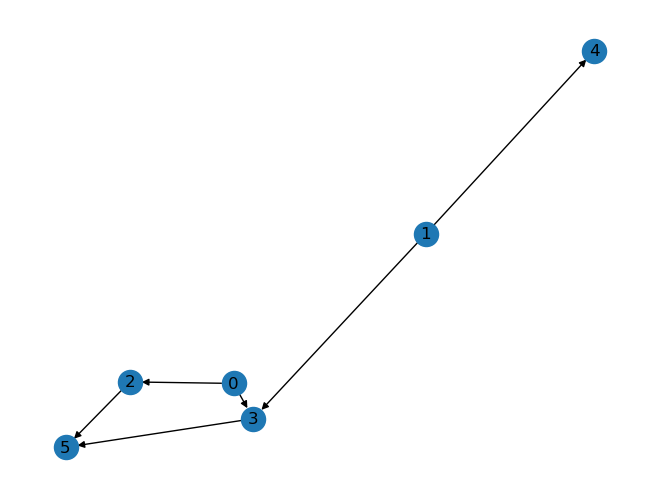

In [56]:
from math import inf

weight_mat_G1 = [
    [0, 1, 0, 0, 1, 1],
    [2, 0, 1, 0, 0, 1],
    [2, 2, 0, 1, 1, 0],
    [2, 1, 1, 0, 1, 0],
    [4, 4, 2, 1, 0, 1],
    [4, 3, 2, 2, 1, 0],
]
n = len(weight_mat_G1)

# Edges are positions where weight is zero (existing edges have zero cost)
edgesG1 = [(i, j) for i in range(n) for j in range(n) 
          if i != j and weight_mat_G1[i][j] == 0]
weightsG1 = lambda x: weight_mat_G1[x[0]][x[1]]

G1 = nx.DiGraph()
G1.add_edges_from(edgesG1)
nx.draw(G1,with_labels=True)

result = greedy_weighted_distributed_graph_augmentation(G1, weightsG1, verbose=True)
added = [e for e in result.edges if e not in edgesG1]
print("Added edges:", added)

## Example 2 - Paper Example 2 (5-node graph, epsilon weights)

===== Round 1 =====

=== Phase 1: SCC computation
[({0}, 'SOURCE'), ({1}, 'MIXED'), ({2}, 'MIXED'), ({3}, 'MIXED'), ({4}, 'TARGET')]

=== Phase 2: shortest-path computation and target proposal
Dijkstra 4 : {4: 0, 2: 1e-10, 3: 1, 0: 1.0000000001, 1: 1.0000000001}
TGTs >>> SRCs : (dist, path)
4 >>> 0 : (1.0000000001, [4, 2, 0])

=== Phase 3: source selection and edge addition
New edges: [(4, 2, 1e-10), (2, 0, 1)]
Round weight: 1.0000000001 


===== Round 2 =====

=== Phase 1: SCC computation
[({0, 1, 2, 3, 4}, 'SOURCE_TARGET')]

=====   END   =====

Total augmentation weight: 1.0000000001
Added edges: [(2, 0), (4, 2)]


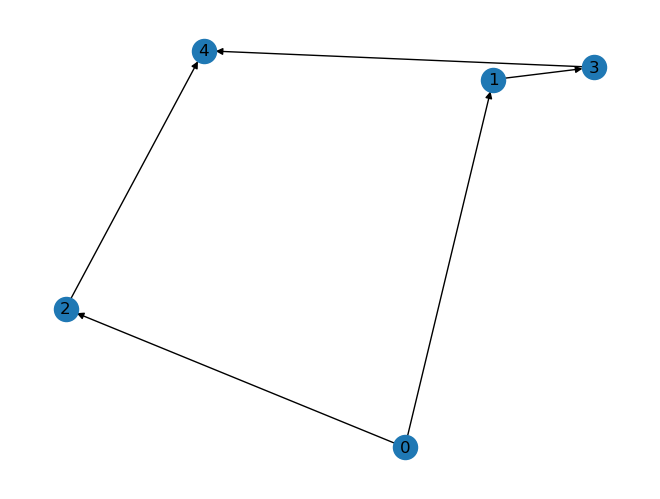

In [57]:
from math import inf
eps = 1e-10

weight_mat_G2 = [
    [0, 0, 0, inf, inf],
    [eps, 0, inf, 0, inf],
    [1, inf, 0, eps, 0],
    [inf, eps, inf, 0, 0],
    [inf, inf, eps, 1, 0],
]
n = len(weight_mat_G2)

# Edges are positions where weight is zero (existing edges have zero cost)
edgesG2 = [(i, j) for i in range(n) for j in range(n) 
          if i != j and weight_mat_G2[i][j] == 0]
weightsG2 = lambda x: weight_mat_G2[x[0]][x[1]]

G2 = nx.DiGraph()
G2.add_edges_from(edgesG2)
nx.draw(G2,with_labels=True)

result = greedy_weighted_distributed_graph_augmentation(G2, weightsG2, verbose=True)
added = [e for e in result.edges if e not in edgesG2]
print("Added edges:", added)

## Example 3 - Weighted augmentation (14-node graph)

===== Round 1 =====

=== Phase 1: SCC computation
[({0, 1}, 'SOURCE'), ({2, 3}, 'SOURCE'), ({4, 5, 6, 7}, 'SOURCE'), ({8, 9, 10}, 'TARGET'), ({11, 12, 13}, 'TARGET')]

=== Phase 2: shortest-path computation and target proposal
Dijkstra 8 : {8: 0, 9: 0, 10: 0, 0: 1, 1: 1, 3: 2, 2: 2, 12: 2}
Dijkstra 11 : {11: 0, 13: 0, 12: 0, 2: 1, 3: 1, 9: 1, 7: 2, 5: 2, 6: 2, 4: 2}
TGTs >>> SRCs : (dist, path)
8 >>> 0 : (1, [8, 9, 0])
11 >>> 2 : (1, [11, 13, 2])

=== Phase 3: source selection and edge addition
New edges: [(8, 9, 2), (9, 0, 1), (11, 13, 2), (13, 2, 1)]
Round weight: 6 


===== Round 2 =====

=== Phase 1: SCC computation
[({0, 1, 8, 9, 10}, 'TARGET'), ({2, 3, 11, 12, 13}, 'MIXED'), ({4, 5, 6, 7}, 'SOURCE')]

=== Phase 2: shortest-path computation and target proposal
Dijkstra 0 : {0: 0, 1: 0, 10: 0, 8: 0, 9: 0, 4: 1, 5: 1, 6: 1, 7: 1, 12: 1, 11: 1, 13: 1, 2: 1, 3: 1}
TGTs >>> SRCs : (dist, path)
0 >>> 4 : (1, [0, 4])

=== Phase 3: source selection and edge addition
New edges: [(0, 4, 1)]

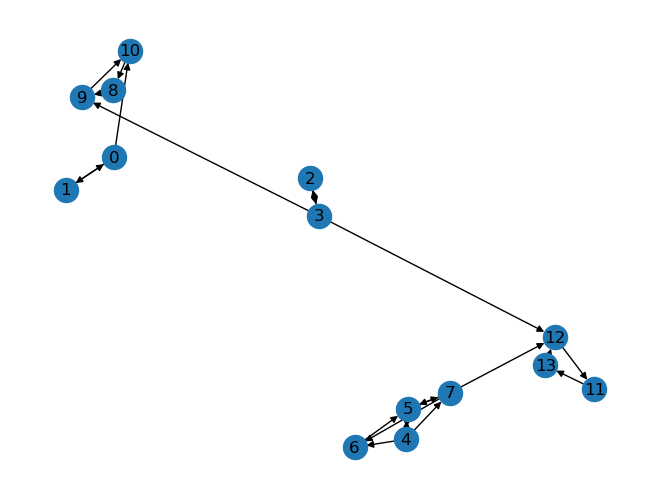

In [58]:
edgesG3 = [(0, 1), (0, 10), (1, 0), (2, 3), (3, 2), (3, 9), (3, 12), 
          (4, 5), (4, 6), (4, 7), (5, 4), (5, 7), (6, 5), (7, 5), 
          (7, 6), (7, 12), (8, 9), (9, 10), (10, 8), (11, 13), 
          (12, 11), (13, 12)]

dic = {(13, 2): 1, (9, 0): 1, (0, 4): 1}
dic = {(k[0], k[1]): v for k, v in dic.items()}
weightsG3 = lambda x: dic[x] if x in dic else 2

G3 = nx.DiGraph()
G3.add_edges_from(edgesG3)
nx.draw(G3,with_labels=True)

result = greedy_weighted_distributed_graph_augmentation(G3, weightsG3, verbose=True)
added = [e for e in result.edges if e not in edgesG3]
print("Added edges:", added)

## Example 4 - Unit-weight augmentation (14-node graph)

===== Round 1 =====

=== Phase 1: SCC computation
[({0}, 'SOURCE'), ({1}, 'SOURCE'), ({2}, 'MIXED'), ({3}, 'MIXED'), ({4}, 'TARGET'), ({5}, 'TARGET')]

=== Phase 2: shortest-path computation and target proposal
Dijkstra 4 : {4: 0, 0: 1, 2: 1, 3: 1, 1: 1, 5: 1}
Dijkstra 5 : {5: 0, 2: 1, 3: 1, 4: 1, 0: 1, 1: 1}
TGTs >>> SRCs : (dist, path)
4 >>> 0 : (1, [4, 0])
5 >>> 0 : (1, [5, 0])

=== Phase 3: source selection and edge addition
New edges: [(4, 0, 1)]
Round weight: 1 


===== Round 2 =====

=== Phase 1: SCC computation
[({0, 3, 4}, 'MIXED'), ({1}, 'SOURCE'), ({2}, 'MIXED'), ({5}, 'TARGET')]

=== Phase 2: shortest-path computation and target proposal
Dijkstra 5 : {5: 0, 2: 1, 3: 1, 4: 1, 0: 1, 1: 1}
TGTs >>> SRCs : (dist, path)
5 >>> 1 : (1, [5, 1])

=== Phase 3: source selection and edge addition
New edges: [(5, 1, 1)]
Round weight: 1 


===== Round 3 =====

=== Phase 1: SCC computation
[({0, 1, 2, 3, 4, 5}, 'SOURCE_TARGET')]

=====   END   =====

Total augmentation weight: 2.0
Added e

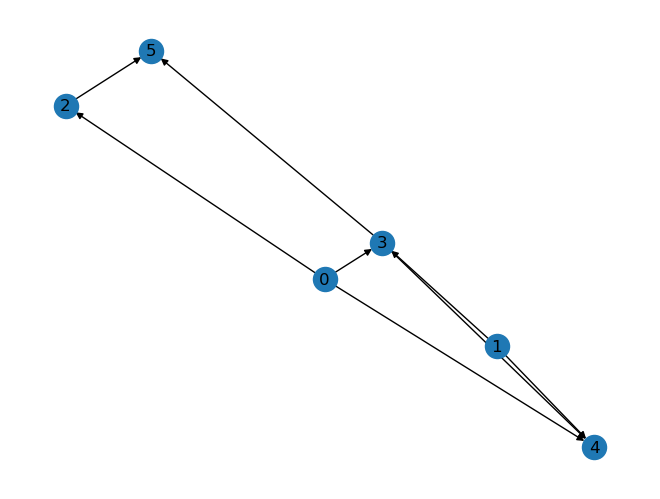

In [53]:
edgesG4 = [(0, 1), (0, 10), (1, 0), (2, 3), (3, 2), (3, 9), (3, 12), (4, 5), 
          (4, 6), (4, 7), (5, 4), (5, 7), (6, 5), (7, 5), (7, 6), (7, 12), 
          (8, 9), (9, 10), (10, 8), (11, 13), (12, 11), (13, 12)]

G4 = nx.DiGraph()
G4.add_edges_from(edges4)
nx.draw(G4,with_labels=True)

result = greedy_weighted_distributed_graph_augmentation(G4, verbose=True)
added = [e for e in result.edges if e not in edgesG4]
print("Added edges:", added)

## Example 5 - Small 6-node graph

===== Round 1 =====

=== Phase 1: SCC computation
[({0}, 'SOURCE'), ({1, 2}, 'TARGET'), ({3, 4}, 'SOURCE'), ({5}, 'TARGET')]

=== Phase 2: shortest-path computation and target proposal
Dijkstra 1 : {1: 0, 2: 0, 0: 1, 5: 1}
Dijkstra 5 : {5: 0, 0: 1, 1: 1, 4: 1, 3: 1}
TGTs >>> SRCs : (dist, path)
1 >>> 0 : (1, [1, 0])
5 >>> 0 : (1, [5, 0])

=== Phase 3: source selection and edge addition
New edges: [(1, 0, 1)]
Round weight: 1 


===== Round 2 =====

=== Phase 1: SCC computation
[({0, 1, 2}, 'SOURCE'), ({3, 4}, 'SOURCE'), ({5}, 'TARGET')]

=== Phase 2: shortest-path computation and target proposal
Dijkstra 5 : {5: 0, 0: 1, 1: 1, 4: 1, 3: 1, 2: 1}
TGTs >>> SRCs : (dist, path)
5 >>> 0 : (1, [5, 0])

=== Phase 3: source selection and edge addition
New edges: [(5, 0, 1)]
Round weight: 1 


===== Round 3 =====

=== Phase 1: SCC computation
[({0, 1, 2, 5}, 'TARGET'), ({3, 4}, 'SOURCE')]

=== Phase 2: shortest-path computation and target proposal
Dijkstra 0 : {0: 0, 1: 0, 5: 0, 2: 0, 4: 1, 3: 1}

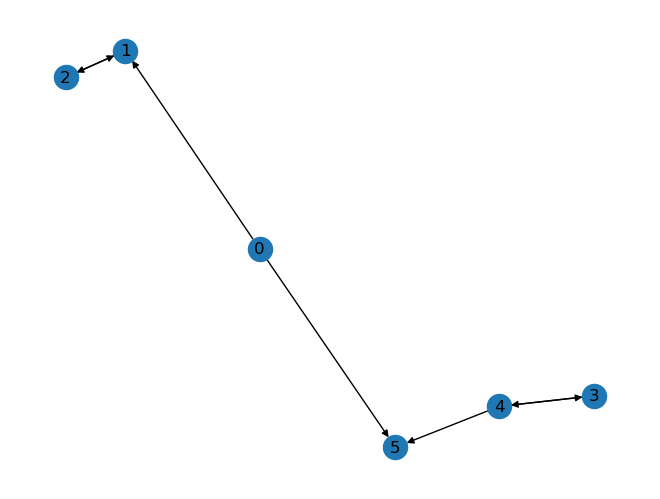

In [54]:
edgesG5 = [(0, 1), (1, 2), (2, 1), (3, 4), (4, 3), (4, 5), (0, 5)]

G5 = nx.DiGraph()
G5.add_edges_from(edgesG5)
nx.draw(G5,with_labels=True)

result = greedy_weighted_distributed_graph_augmentation(G5, verbose=True)
added = [e for e in result.edges if e not in edgesG5]
print("Added edges:", added)

## Example 6 - Weight-matrix input (6-node graph)

===== Round 1 =====

=== Phase 1: SCC computation
[({0}, 'SOURCE'), ({1}, 'SOURCE'), ({2}, 'MIXED'), ({3}, 'MIXED'), ({4}, 'TARGET'), ({5}, 'TARGET')]

=== Phase 2: shortest-path computation and target proposal
Dijkstra 4 : {4: 0, 2: 1, 3: 1, 5: 1, 1: 2, 0: 3}
Dijkstra 5 : {5: 0, 2: 2, 3: 2, 4: 2, 1: 3, 0: 4}
TGTs >>> SRCs : (dist, path)
4 >>> 1 : (2, [4, 3, 1])
5 >>> 1 : (3, [5, 1])

=== Phase 3: source selection and edge addition
New edges: [(4, 3, 1), (3, 1, 1)]
Round weight: 2 


===== Round 2 =====

=== Phase 1: SCC computation
[({0}, 'SOURCE'), ({1, 3, 4}, 'MIXED'), ({2}, 'MIXED'), ({5}, 'TARGET')]

=== Phase 2: shortest-path computation and target proposal
Dijkstra 5 : {5: 0, 2: 2, 3: 2, 4: 2, 1: 2, 0: 4}
TGTs >>> SRCs : (dist, path)
5 >>> 0 : (4, [5, 0])

=== Phase 3: source selection and edge addition
New edges: [(5, 0, 4)]
Round weight: 4 


===== Round 3 =====

=== Phase 1: SCC computation
[({0, 1, 2, 3, 4, 5}, 'SOURCE_TARGET')]

=====   END   =====

Total augmentation weigh

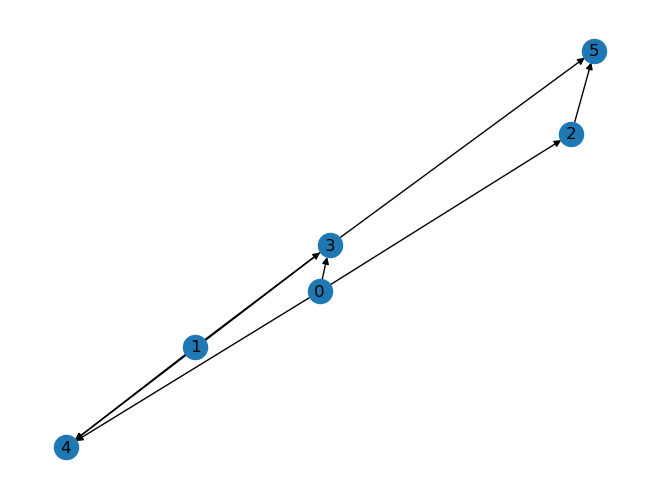

In [55]:
weight_mat_G6 = [
    [0, 1, 0, 0, 0, 1],
    [2, 0, 1, 0, 0, 1],
    [2, 2, 0, 2, 2, 0],
    [2, 1, 2, 0, 0, 0],
    [3, 3, 1, 1, 0, 1],
    [4, 3, 2, 2, 2, 0],
]
n = len(weight_mat_G6)

# Edges are positions where weight is zero (existing edges have zero cost)
edgesG6 = [(i, j) for i in range(n) for j in range(n) 
          if i != j and weight_mat_G6[i][j] == 0]
weightsG6 = lambda x: weight_mat_G6[x[0]][x[1]]

G6 = nx.DiGraph()
G6.add_edges_from(edgesG6)
nx.draw(G6,with_labels=True)

result = greedy_weighted_distributed_graph_augmentation(G6, weightsG6, verbose=True)
added = [e for e in result.edges if e not in edgesG6]
print("Added edges:", added)